<a href="https://colab.research.google.com/github/shahabday/DSR-practical-computer-vision/blob/main/scratchpad_pet_breed_classification_and_wandb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Check Kaggle Jupyter Server Setup

In [ ]:
# pwd = print working directory in bash
!pwd

/content


In [ ]:
# This will only work if there is a GPU
# !nvidia-smi

In [ ]:
# Access the W&B API key from Colab secrets
import wandb
import os
from google.colab import userdata

# Get API key from secrets
api_key = userdata.get('wandb_api')

# Set the environment variable
os.environ["WANDB_API_KEY"] = api_key

# Verify login
wandb.login()

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


True

```python
# Optional: Access the W&B API key from Kaggle secrets
from kaggle_secrets import UserSecretsClient

# Get API key from secrets
secret_label = "wandb_api"
secret_value = UserSecretsClient().get_secret(secret_label)
```

In [ ]:
import os
import io
import random
import numpy as np
import pandas as pd
import skimage.io as io
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.notebook import tqdm
from google.colab import userdata
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import OneCycleLR
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import v2 as transforms
from torchvision import models
from torchvision.datasets import OxfordIIITPet
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, accuracy_score
from tqdm import tqdm
from transformers import CLIPModel, CLIPProcessor


In [ ]:
# Set random seeds for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()

## Initialize wandb

In [ ]:
#TODO: Actually use these values
config = {
               "architecture": "resnet18",
               "dataset": "OxfordIIITPet",
               "initial_learning_rate": 0.001,
               'max_learning_rate': 0.01,
               "epochs": 10,
               "batch_size": 32,
               "optimizer": "Adam",
               "scheduler": "OneCycleLR",
               "loss_function": "CrossEntropyLoss"
           }

In [ ]:
# We use this to start wandb and specify the project that logs our experiments
wandb.init(project='dsr-pets-breed-classification-oxford-dataset',
           # Folder inside the project, if left empty will be a randomly generated name
           #name='supervised-learning',
           # config has the hyperparameters that give a brief overview of what we are doing
           config=config)

## Define data transformations

In [ ]:
# Data Preparation
# Define transformations applied to all sets during training and evaluation with DataLoaders
# These transformations are to be applied 'on the fly', ideally these would be persisted on disk
# before training and evaluation, so that we can carefully explore the datasets, their relationships with one another
# and the model's performance

# We apply Imagenet normalization on all sets (train, test, and val)

# We do data augmentation in the training set only
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    # Random transformations should only be applied on the training set
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    #
    transforms.ToImage(),
    # ToDtype turns the uint8 tensors to torch.float32 range
    # and scales them in the range [0.0, 1.0] by dividing all intensities with 255.
    transforms.ToDtype(torch.float32, scale=True),
    # This applies the standard scaler considering the Imagenet stats for R, G, B intensities
    # We need to do this because we are doing transfer learning, we are going to be using
    # an Imagenet pretrained model and we benefit from making our R, G, B intensities be in the same scale
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# The transformations that we apply in the validation and test sets
# are meant to keep evaluations of cross entropy loss and performance metrics consisten
val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToImage(),
    transforms.ToDtype(torch.float32, scale=True),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

## Load the dataset from torchvision

In [ ]:
exec('from torchvision.datasets import ' + config['dataset'])

In [ ]:
# Open question: should we create the validation set out of trainval or out of the test set?
train_dataset = OxfordIIITPet(root='./data', split='trainval', transform=train_transforms, download=True)
val_test_dataset = OxfordIIITPet(root='./data', split='test', transform=val_test_transforms, download=True)

In [ ]:
val_test_dataset.transform

Compose(
      Resize(size=[224, 224], interpolation=InterpolationMode.BILINEAR, antialias=True)
      ToImage()
      ToDtype(scale=True)
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], inplace=False)
)

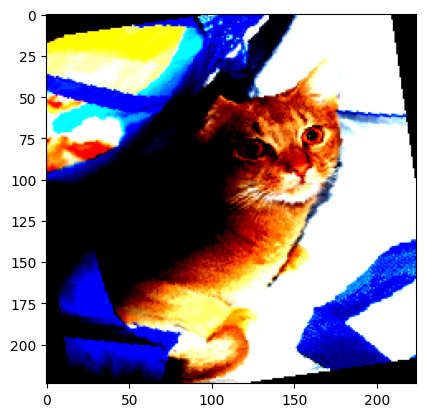

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(train_dataset[0][0].permute(1, 2, 0));

## Create validation set

In [ ]:
test_size = int(0.5 * len(val_test_dataset))
val_size = len(val_test_dataset) - test_size
test_size, val_size

(1834, 1835)

```python TODO: Make stratified sampling work
from sklearn.model_selection import train_test_split

# Assuming 'targets' is a list/array of your target labels
train_indices, val_indices, _, _ = train_test_split(
    range(len(trainval_dataset)),
    labels, # or a list with your labels
    test_size=val_size,  # your desired validation set size
    stratify=trainval_dataset.classes,  # Ensure stratified split
    random_state=42  # for reproducibility
)

train_dataset = torch.utils.data.Subset(trainval_dataset, train_indices)
val_dataset = torch.utils.data.Subset(trainval_dataset, val_indices)
```

In [ ]:
test_dataset, val_dataset = torch.utils.data.random_split(val_test_dataset, [test_size, val_size])

## Transformations for each set

In [ ]:
# Here we override the transformation that was originally assigned to the test validation set
# Transformations don't get 'trigggered' until we call __getitem__ on elements of the dataset
val_dataset.transform = val_test_transforms
val_dataset.transform

Compose(
      Resize(size=[224, 224], interpolation=InterpolationMode.BILINEAR, antialias=True)
      ToImage()
      ToDtype(scale=True)
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], inplace=False)
)

In [ ]:
# calling an index on the dataset calls the __getitem__ method
val_dataset[0]

(Image([[[-0.4226, -0.4397, -0.4397,  ..., -0.6794, -0.6965, -0.7308],
         [-0.4397, -0.4397, -0.4226,  ..., -0.6452, -0.6623, -0.6965],
         [-0.4054, -0.3883, -0.3712,  ..., -0.6452, -0.6452, -0.6623],
         ...,
         [-1.8953, -1.7240, -1.6555,  ..., -1.7754, -1.7583, -1.6213],
         [-1.6555, -1.6727, -1.6555,  ..., -1.7240, -1.7069, -1.6555],
         [-1.6384, -1.6042, -1.5699,  ..., -1.6555, -1.7583, -1.6727]],
 
        [[-0.1800, -0.1800, -0.1625,  ..., -0.4951, -0.5126, -0.5476],
         [-0.1800, -0.1800, -0.1450,  ..., -0.4601, -0.4776, -0.5126],
         [-0.1275, -0.1275, -0.0924,  ..., -0.4426, -0.4601, -0.4776],
         ...,
         [-1.7906, -1.6506, -1.6331,  ..., -1.6155, -1.6331, -1.5105],
         [-1.6155, -1.5805, -1.5455,  ..., -1.6155, -1.5455, -1.4755],
         [-1.5455, -1.5105, -1.5105,  ..., -1.5630, -1.6506, -1.5105]],
 
        [[ 0.1476,  0.1651,  0.1825,  ..., -0.2184, -0.2358, -0.2707],
         [ 0.1651,  0.1825,  0.1999,  ..., 

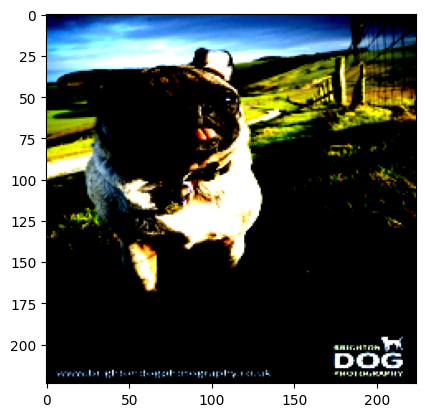

In [ ]:
# Check that the transformations applied to the validation set are deteministic
plt.imshow(val_dataset[0][0].permute(1, 2, 0))

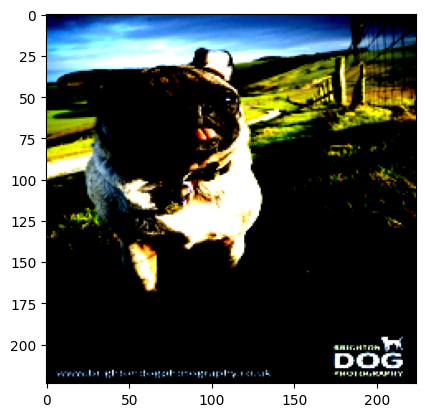

In [ ]:
plt.imshow(val_dataset[0][0].permute(1, 2, 0))

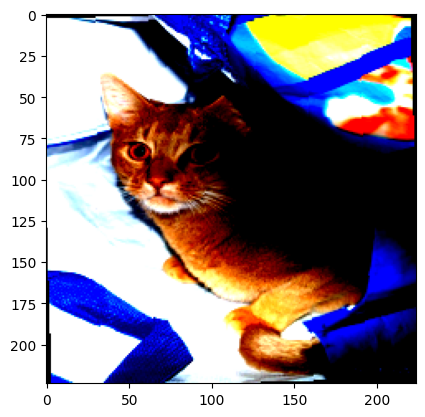

In [ ]:
# Check that the transformations on the training set are non-deterministic
# We want to augment this data during training
plt.imshow(train_dataset[0][0].permute(1, 2, 0))

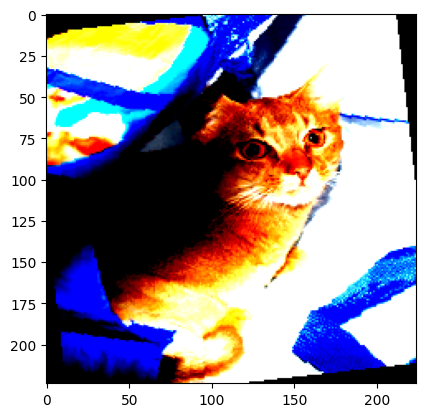

In [ ]:
plt.imshow(train_dataset[0][0].permute(1, 2, 0))

## Create DataLoaders

In [ ]:
# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset,     batch_size=32, shuffle=False, num_workers=4)
test_loader = DataLoader(test_dataset,   batch_size=32, shuffle=False, num_workers=4)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Testing samples: {len(test_dataset)}")

Training samples: 3680
Validation samples: 1835
Testing samples: 1834


In [ ]:
# These are the breeds of dogs and cats considered in the Oxford-IIT pets dataset
oxford_pets_classes = [
    ("Abyssinian", "cat"),
    ("American Bulldog", "dog"),
    ("American Pit Bull Terrier", "dog"),
    ("Basset Hound", "dog"),
    ("Beagle", "dog"),
    ("Bengal", "cat"),
    ("Birman", "cat"),
    ("Bombay", "cat"),
    ("Boxer", "dog"),
    ("British Shorthair", "cat"),
    ("Chihuahua", "dog"),
    ("Egyptian Mau", "cat"),
    ("English Cocker Spaniel", "dog"),
    ("English Setter", "dog"),
    ("German Shorthaired", "dog"),
    ("Great Pyrenees", "dog"),
    ("Havanese", "dog"),
    ("Japanese Chin", "dog"),
    ("Keeshond", "dog"),
    ("Leonberger", "dog"),
    ("Maine Coon", "cat"),
    ("Miniature Pinscher", "dog"),
    ("Newfoundland", "dog"),
    ("Persian", "cat"),
    ("Pomeranian", "dog"),
    ("Pug", "dog"),
    ("Ragdoll", "cat"),
    ("Russian Blue", "cat"),
    ("Saint Bernard", "dog"),
    ("Samoyed", "dog"),
    ("Scottish Terrier", "dog"),
    ("Shiba Inu", "dog"),
    ("Siamese", "cat"),
    ("Sphynx", "cat"),
    ("Staffordshire Bull Terrier", "dog"),
    ("Wheaten Terrier", "dog"),
    ("Yorkshire Terrier", "dog")
]

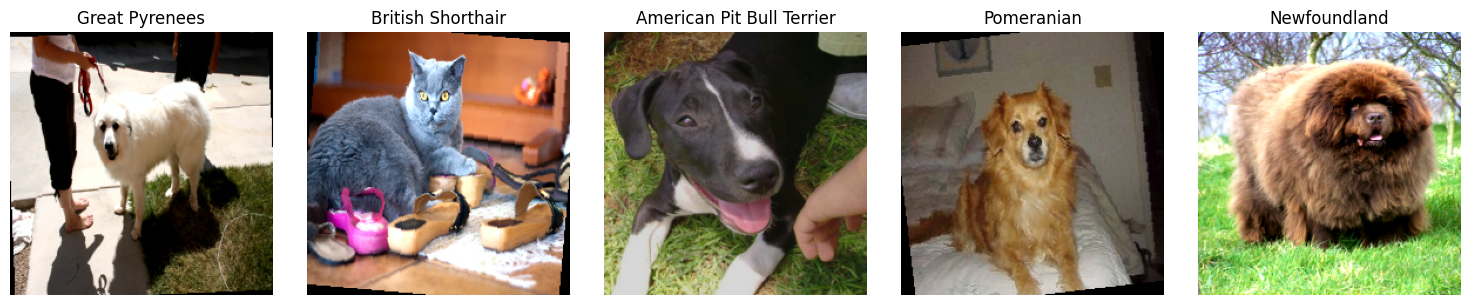

In [ ]:
# Display some sample images
def display_sample_images(dataset, num_samples=5):
    fig, axes = plt.subplots(1, num_samples, figsize=(15, 3))
    for i in range(num_samples):
        idx = random.randint(0, len(dataset) - 1)
        img, label = dataset[idx]
        img = img.permute(1, 2, 0).numpy()  # Convert from CxHxW to HxWxC
        img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])  # Denormalize
        img = np.clip(img, 0, 1)
        axes[i].imshow(img)
        axes[i].set_title(f"{oxford_pets_classes[label][0]}")
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()

display_sample_images(train_dataset)

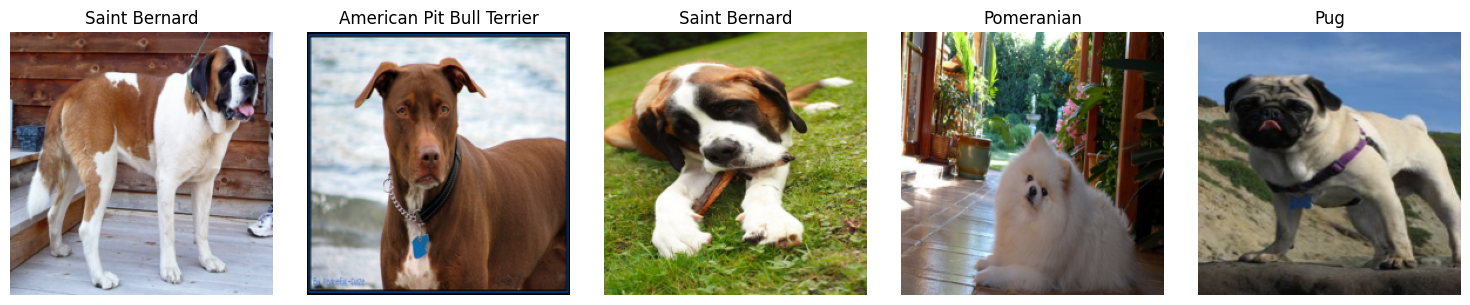

In [ ]:
display_sample_images(val_dataset)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [ ]:
# Model definition
class PetClassifier(nn.Module):
    def __init__(self, num_classes=37):
        super(PetClassifier, self).__init__()
        # Load a pre-trained ResNet18 model
        self.backbone = models.resnet18(weights='IMAGENET1K_V1')

        # Freeze the early layers
        for param in list(self.backbone.parameters())[:-20]:
            param.requires_grad = False

        # Replace the final fully connected layer
        num_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Dropout(0.25),
            nn.Linear(num_features, 256),  # New hidden layer with 256 units
            nn.ReLU(),  # Activation function for the hidden layer
            nn.Dropout(0.25),
            nn.Linear(256, num_classes)  # Output layer
        )

    def forward(self, x):
        return self.backbone(x)

# Initialize the model
model = PetClassifier(num_classes=37).to(device)
# Check the architecture of the model
model


PetClassifier(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, tr

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=config['initial_learning_rate'])

In [ ]:
config['initial_learning_rate']

0.001

In [ ]:
num_epochs = config['epochs']
scheduler = OneCycleLR(optimizer, max_lr=0.01, total_steps=len(train_loader)*num_epochs)

In [ ]:
# Training loop
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in tqdm(dataloader, desc="Training"):
        inputs, labels = inputs.to(device), labels.to(device)

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        # Statistics
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [ ]:
# Validation/Testing function
def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.inference_mode():
        for inputs, labels in tqdm(dataloader, desc="Evaluating"):
            inputs, labels = inputs.to(device), labels.to(device)

            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # Statistics
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Calculate metrics
    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_precision = precision_score(all_labels, all_preds, average='weighted')
    epoch_recall = recall_score(all_labels, all_preds, average='weighted')
    cm = confusion_matrix(all_labels, all_preds)

    return epoch_loss, epoch_acc, epoch_precision, epoch_recall, cm, all_preds, all_labels

### Run the training loop with wandb logging

In [ ]:
best_val_loss = float('inf')
train_losses = []
val_losses = []

In [ ]:
for epoch in range(config['epochs']):
    print(f"Epoch {epoch+1}/{num_epochs}")

    # Train one epoch
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)

    # Evaluate on validation set
    val_loss, val_acc, val_precision, val_recall, val_cm, _, _ = evaluate(model, val_loader, criterion, device)

    # Update learning rate based on validation loss
    scheduler.step(val_loss)

    # Log metrics to W&B
    wandb.log({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_accuracy": train_acc,
        "val_loss": val_loss,
        "val_accuracy": val_acc,
        "val_precision": val_precision,
        "val_recall": val_recall,
        "learning_rate": optimizer.param_groups[0]['lr']
    })

    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}, Val Precision: {val_precision:.4f}, Val Recall: {val_recall:.4f}")

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        # Save locally
        torch.save(model.state_dict(), 'best_model.pth')
        # Save to wandb
        wandb.save('best_model.pth')
        print("Saved best model locally and to wandb!")



Epoch 1/10


Evaluating: 100%|██████████| 58/58 [00:03<00:00, 17.41it/s]


Train Loss: 1.7516, Train Acc: 0.5489
Val Loss: 0.7221, Val Acc: 0.7858, Val Precision: 0.8244, Val Recall: 0.7858
Saved best model locally and to wandb!
Epoch 2/10


Evaluating: 100%|██████████| 58/58 [00:03<00:00, 15.99it/s]


Train Loss: 0.6108, Train Acc: 0.8122
Val Loss: 0.6522, Val Acc: 0.7787, Val Precision: 0.8050, Val Recall: 0.7787
Saved best model locally and to wandb!
Epoch 3/10


...

Train Loss: 0.1024, Train Acc: 0.9690
Val Loss: 0.7398, Val Acc: 0.8054, Val Precision: 0.8314, Val Recall: 0.8054
Epoch 9/10


Evaluating: 100%|██████████| 58/58 [00:03<00:00, 18.06it/s]


Train Loss: 0.1083, Train Acc: 0.9655
Val Loss: 0.6952, Val Acc: 0.8196, Val Precision: 0.8382, Val Recall: 0.8196
Epoch 10/10


Evaluating: 100%|██████████| 58/58 [00:03<00:00, 18.32it/s]

Train Loss: 0.1326, Train Acc: 0.9628
Val Loss: 0.7550, Val Acc: 0.8044, Val Precision: 0.8235, Val Recall: 0.8044


In [ ]:
wandb.finish()

epoch,▁▂▃▃▄▅▆▆▇█▁▂▃▃▄▅▆▆▇█
learning_rate,▆▃▃▁▃▁▄▇▅█▆▃▃▁▃▁▄▇▅█
train_accuracy,▁▅▇▇▇█████▁▅▇▇▇█████
train_loss,█▃▂▂▁▁▁▁▁▁█▃▂▂▁▁▁▁▁▁
val_accuracy,▂▁▄▇▇█▇▅█▅▂▁▄▇▇█▇▅█▅
val_loss,▆▃▃▁▄▁▄▇▅█▆▃▃▁▄▁▄▇▅█
val_precision,▅▁▄▆█▆▇▇█▅▅▁▄▆█▆▇▇█▅
val_recall,▂▁▄▇▇█▇▅█▅▂▁▄▇▇█▇▅█▅
epoch,10
learning_rate,0.0004
train_accuracy,0.96277
